In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score

from imblearn.over_sampling import SMOTE

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

In [14]:
spark = SparkSession.builder \
    .appName("DiabetesPrediction") \
    .config("spark.executor.memory","8g") \
    .config("spark.driver.memory","8g") \
    .getOrCreate()

In [16]:
df = pd.read_csv("/content/diabetes_dataset.csv")

print("Original dataset shape:", df.shape)

Original dataset shape: (100000, 16)


In [17]:
df = df.dropna()

print("Dataset shape after removing null values:", df.shape)

Dataset shape after removing null values: (100000, 16)


In [19]:
df.head()
df.describe()

,year,age,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2018.360820,41.885856,0.202230,0.200150,0.198760,0.19888,0.199980,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,1.345239,22.516840,0.401665,0.400114,0.399069,0.39916,0.399987,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,2015.000000,0.080000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,2019.000000,24.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,2019.000000,43.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,2019.000000,60.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,2022.000000,80.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [20]:
df_processed = pd.get_dummies(df, columns=['gender', 'location', 'smoking_history'], drop_first=True)

print("DataFrame columns after one-hot encoding:", df_processed.columns.tolist())

DataFrame columns after one-hot encoding: ['year', 'age', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'hypertension', 'heart_disease', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'diabetes', 'gender_Male', 'gender_Other', 'location_Alaska', 'location_Arizona', 'location_Arkansas', 'location_California', 'location_Colorado', 'location_Connecticut', 'location_Delaware', 'location_District of Columbia', 'location_Florida', 'location_Georgia', 'location_Guam', 'location_Hawaii', 'location_Idaho', 'location_Illinois', 'location_Indiana', 'location_Iowa', 'location_Kansas', 'location_Kentucky', 'location_Louisiana', 'location_Maine', 'location_Maryland', 'location_Massachusetts', 'location_Michigan', 'location_Minnesota', 'location_Mississippi', 'location_Missouri', 'location_Montana', 'location_Nebraska', 'location_Nevada', 'location_New Hampshire', 'location_New Jersey', 'location_New Mexico', 'location_New York', 'location_North Carolina', 'loca

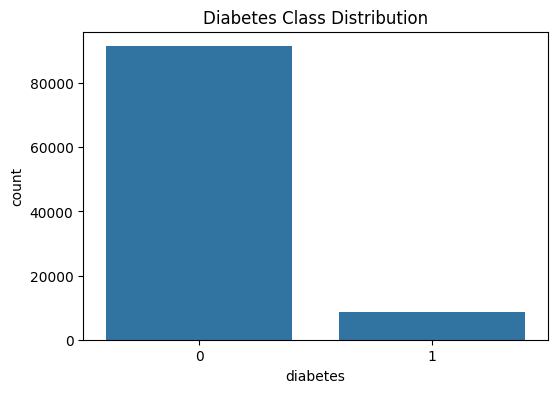

Counter({0: 91500, 1: 8500})


In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x="diabetes", data=df_processed)
plt.title("Diabetes Class Distribution")
plt.show()
print(Counter(df_processed["diabetes"]))

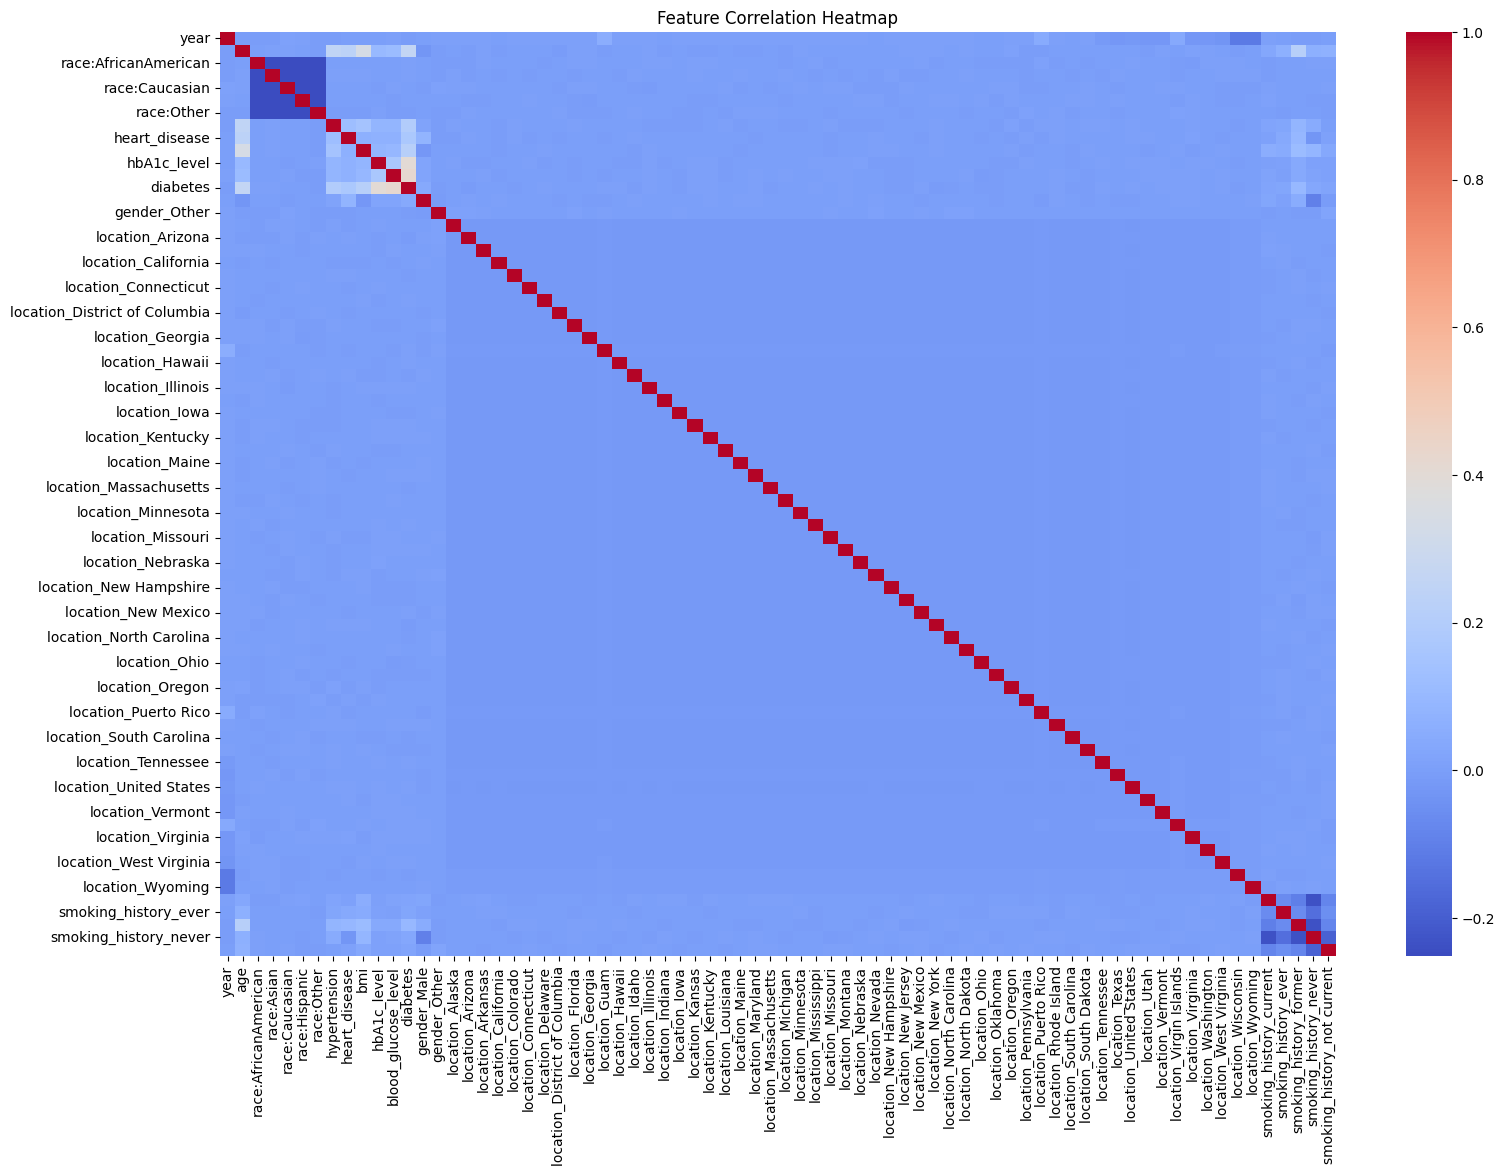

In [22]:
plt.figure(figsize=(18,12))
sns.heatmap(df_processed.corr(), cmap="coolwarm", annot=False, fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

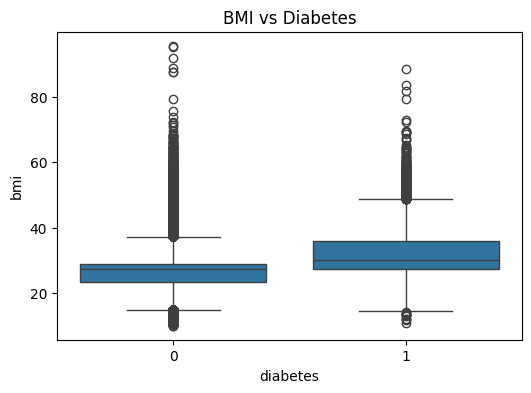

In [23]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x="diabetes",
    y="bmi",
    data=df_processed
)
plt.title("BMI vs Diabetes")
plt.show()

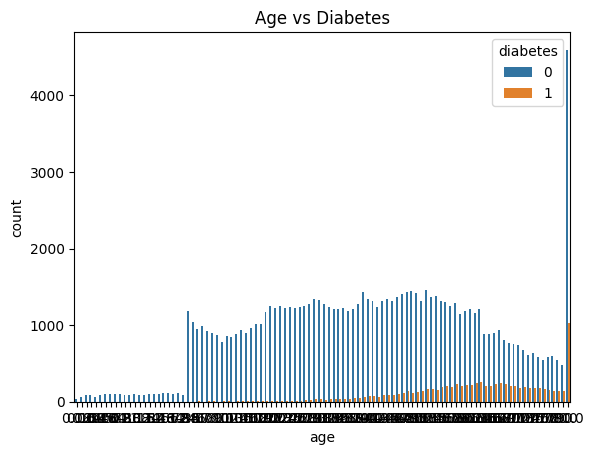

In [24]:
sns.countplot(
    x="age",
    hue="diabetes",
    data=df_processed
)
plt.title("Age vs Diabetes")
plt.show()

In [25]:
X = df_processed.drop("diabetes", axis=1)
y = df_processed["diabetes"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training distribution:", Counter(y_train))
print("Testing distribution:", Counter(y_test))

Training distribution: Counter({0: 73200, 1: 6800})
Testing distribution: Counter({0: 18300, 1: 1700})


In [44]:
from pyspark.ml.classification import LinearSVC

svm = LinearSVC(
    labelCol="diabetes",
    featuresCol="features",
    maxIter=10,
    regParam=0.1
)
svm_model = svm.fit(train_spark)
print("Linear SVM trained successfully")

Linear SVM trained successfully


In [45]:
svm_predictions = svm_model.transform(test_spark)
svm_predictions.select(
    "diabetes",
    "prediction"
).show(10)

+--------+----------+
|diabetes|prediction|
+--------+----------+
|       0|       0.0|
|       0|       0.0|
|       0|       0.0|
|       0|       0.0|
|       0|       0.0|
|       0|       0.0|
|       0|       0.0|
|       1|       0.0|
|       0|       0.0|
|       0|       0.0|
+--------+----------+
only showing top 10 rows


In [46]:
svm_pred_pd = svm_predictions.select(
    "diabetes",
    "prediction"
).toPandas()
svm_pred_pd_cleaned = svm_pred_pd.dropna(subset=["diabetes"])
svm_accuracy = accuracy_score(
    svm_pred_pd_cleaned["diabetes"],
    svm_pred_pd_cleaned["prediction"]
)
print("Linear SVM Accuracy:", svm_accuracy)

Linear SVM Accuracy: 0.95735


In [26]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)
print("After SMOTE:", Counter(y_train_smote))

After SMOTE: Counter({1: 73200, 0: 73200})


In [27]:
scaler = StandardScaler()
X_train_smote = scaler.fit_transform(X_train_smote)
X_test = scaler.transform(X_test)

In [28]:
y_train_smote = y_train_smote.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [29]:
train_pd = pd.DataFrame(X_train_smote, columns=X.columns)
train_pd["diabetes"] = y_train_smote

test_pd = pd.DataFrame(X_test, columns=X.columns)
test_pd["diabetes"] = y_test

train_spark = spark.createDataFrame(train_pd)
test_spark = spark.createDataFrame(test_pd)

In [30]:
feature_cols = [c for c in train_spark.columns if c != "diabetes"]
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)
train_spark = assembler.transform(train_spark)
test_spark = assembler.transform(test_spark)
train_spark = train_spark.select("features","diabetes")
test_spark = test_spark.select("features","diabetes")

train_spark = train_spark.cache()

In [31]:
rf = RandomForestClassifier(
    labelCol="diabetes",
    featuresCol="features",
    numTrees=150,
    maxDepth=10,
    seed=42
)
rf_model = rf.fit(train_spark)
print("Random Forest trained successfully")

Random Forest trained successfully


In [32]:
predictions = rf_model.transform(test_spark)
predictions.select(
    "diabetes",
    "prediction",
    "probability"
).show(10)

+--------+----------+--------------------+
|diabetes|prediction|         probability|
+--------+----------+--------------------+
|       0|       0.0|[0.86624811758717...|
|       0|       0.0|[0.94411321641615...|
|       0|       0.0|[0.77618414397021...|
|       0|       0.0|[0.96376914311644...|
|       0|       0.0|[0.77849921210356...|
|       0|       0.0|[0.62517625593453...|
|       0|       0.0|[0.88931613034296...|
|       1|       0.0|[0.77863156645440...|
|       0|       0.0|[0.83855952830932...|
|       0|       0.0|[0.87392054217803...|
+--------+----------+--------------------+
only showing top 10 rows


In [33]:
pred_pd = predictions.select(
    "diabetes",
    "prediction"
).toPandas()
pred_pd_cleaned = pred_pd.dropna(subset=["diabetes"])
accuracy = accuracy_score(
    pred_pd_cleaned["diabetes"],
    pred_pd_cleaned["prediction"]
)
print("Random Forest Accuracy:", accuracy)

Random Forest Accuracy: 0.94155


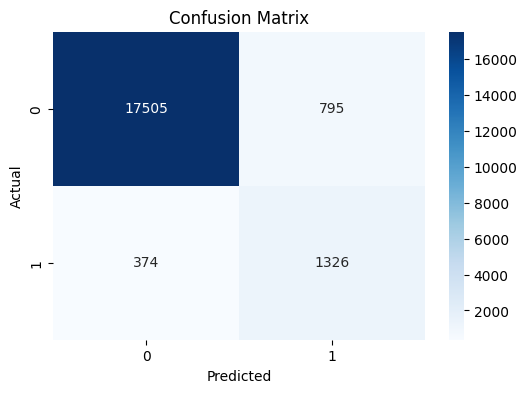

In [34]:
cm = confusion_matrix(
    pred_pd_cleaned["diabetes"],
    pred_pd_cleaned["prediction"]
)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [35]:
gbt = GBTClassifier(
    labelCol="diabetes",
    featuresCol="features",
    maxIter=10,
    maxDepth=5,
    seed=42
)
gbt_model = gbt.fit(train_spark)
print("GBT Classifier trained successfully")

GBT Classifier trained successfully


In [36]:
gbt_predictions = gbt_model.transform(test_spark)
gbt_predictions.select(
    "diabetes",
    "prediction",
    "probability"
).show(10)

+--------+----------+--------------------+
|diabetes|prediction|         probability|
+--------+----------+--------------------+
|       0|       0.0|[0.86963167363940...|
|       0|       0.0|[0.93292129372035...|
|       0|       0.0|[0.94473530557085...|
|       0|       0.0|[0.93249929120969...|
|       0|       0.0|[0.91877326477843...|
|       0|       0.0|[0.75585244204559...|
|       0|       0.0|[0.91674370850734...|
|       1|       0.0|[0.77132966971667...|
|       0|       0.0|[0.83004487255613...|
|       0|       0.0|[0.92911080688622...|
+--------+----------+--------------------+
only showing top 10 rows


In [37]:
gbt_pred_pd = gbt_predictions.select(
    "diabetes",
    "prediction"
).toPandas()
gbt_pred_pd_cleaned = gbt_pred_pd.dropna(subset=["diabetes"])
gbt_accuracy = accuracy_score(
    gbt_pred_pd_cleaned["diabetes"],
    gbt_pred_pd_cleaned["prediction"]
)
print("GBT Accuracy:", gbt_accuracy)

GBT Accuracy: 0.93415


In [39]:
rf_tuned_predictions = best_rf_model.transform(test_spark)
roc_auc = evaluator.evaluate(rf_tuned_predictions)
print(f"Area Under ROC on test set with best RandomForest: {roc_auc}")
rf_tuned_pred_pd = rf_tuned_predictions.select(
    "diabetes",
    "prediction"
).toPandas()
rf_tuned_pred_pd_cleaned = rf_tuned_pred_pd.dropna(subset=["diabetes"])
rf_tuned_accuracy = accuracy_score(
    rf_tuned_pred_pd_cleaned["diabetes"],
    rf_tuned_pred_pd_cleaned["prediction"]
)
print("Random Forest Tuned Accuracy:", rf_tuned_accuracy)

Area Under ROC on test set with best RandomForest: 0.9606718739955009
Random Forest Tuned Accuracy: 0.93745


In [48]:
import zipfile
import os

# Save SVM model before zipping
# Note: Assuming svm_model variable exists from previous execution
if 'svm_model' in globals():
    svm_model.write().overwrite().save("/content/svm_model")
    print("Linear SVM Model saved to /content/svm_model")
else:
    print("Warning: svm_model object not found in current session. Cannot save.")

model_paths = [
    "/content/random_forest_model",
    "/content/gbt_model",
    "/content/tuned_random_forest_model",
    "/content/svm_model" # Include SVM model if it exists
]

zip_file_name = "/content/trained_models.zip"

with zipfile.ZipFile(zip_file_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for model_path in model_paths:
        if os.path.exists(model_path):
            for root, dirs, files in os.walk(model_path):
                for file in files:
                    file_path = os.path.join(root, file)
                    zipf.write(file_path, os.path.relpath(file_path, os.path.dirname(model_path)))
            print(f"Added {model_path} to the zip archive.")
        else:
            print(f"Warning: Model path {model_path} not found. Skipping.")

print(f"All trained models have been zipped into {zip_file_name}")

Added /content/random_forest_model to the zip archive.
Added /content/gbt_model to the zip archive.
Added /content/tuned_random_forest_model to the zip archive.
All trained models have been zipped into /content/trained_models.zip


In [47]:
rf_model.write().overwrite().save("/content/random_forest_model")
print("Random Forest Model saved to /content/random_forest_model")

gbt_model.write().overwrite().save("/content/gbt_model")
print("GBT Model saved to /content/gbt_model")

best_rf_model.write().overwrite().save("/content/tuned_random_forest_model")
print("Tuned Random Forest Model saved to /content/tuned_random_forest_model")

Random Forest Model saved to /content/random_forest_model
GBT Model saved to /content/gbt_model
Tuned Random Forest Model saved to /content/tuned_random_forest_model
